In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

/Users/florentinafabregas/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
data_path = '../data/movement.csv'
movement_df = pd.read_csv(data_path)
movement_df.head(2)

,licencePlate,car_type,vehicleTypeId,start_move_time,end_move_time,start_lat,start_lon,end_lat,end_lon,start_zip,end_zip,start_area_name,end_area_name,move_duration
0,bn32098,car,2,7/22/2025 9:13,7/22/2025 9:17,55.658398,12.514628,55.658348,12.515684,2500,2500,Valby,Valby,0 days 00:04:00
1,bn32098,car,2,7/22/2025 9:19,7/22/2025 9:23,55.658348,12.515684,55.659286,12.519309,2500,1805,Valby,Frederiksberg C,0 days 00:04:00


In [7]:
movement_df.columns

Index(['licencePlate', 'car_type', 'vehicleTypeId', 'start_move_time',
       'end_move_time', 'start_lat', 'start_lon', 'end_lat', 'end_lon',
       'start_zip', 'end_zip', 'start_area_name', 'end_area_name',
       'move_duration'],
      dtype='object')

In [5]:
n_cars = movement_df['licencePlate'].nunique()
print('Number of cars: ', n_cars
)

Number of cars:  1309


In [8]:
# Daily aggreagates on daily_use dataframe
movement_df['move_duration'] = pd.to_timedelta(movement_df['move_duration'])
movement_df['start_move_time'] = pd.to_datetime(movement_df['start_move_time'])
movement_df['end_move_time'] = pd.to_datetime(movement_df['end_move_time'])

movement_df['rental_minutes'] = movement_df['move_duration'].dt.total_seconds() / 60
movement_df['date'] = movement_df['start_move_time'].dt.date

daily_use = movement_df.groupby('date')['rental_minutes'].sum().reset_index()
daily_use['total_hours'] = daily_use['rental_minutes'] / 60
daily_use['av_rent_hour_per_car'] = daily_use['total_hours'] / n_cars

In [ ]:
daily_use.head(2)

,date,rental_minutes,total_hours,av_rent_hour_per_car
0,2025-07-21,134690.100000,2244.835000,1.714924
1,2025-07-22,368594.666667,6143.244444,4.693082


### 7-day smoothing

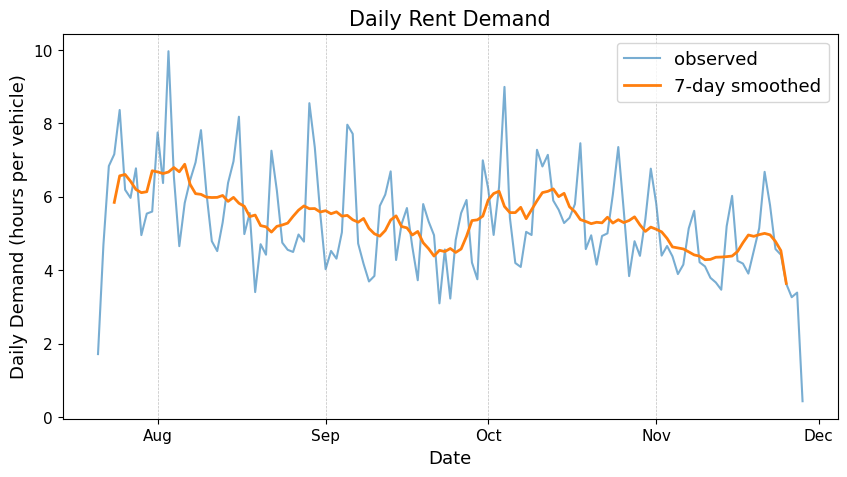

In [42]:
daily_use = daily_use.sort_values('date')
daily_use['rental_smooth'] = daily_use['av_rent_hour_per_car'].rolling(window=7, center=True).mean()

plt.figure(figsize=(10,5))
plt.plot(daily_use['date'], daily_use['av_rent_hour_per_car'], label='observed', alpha=0.6)
plt.plot(daily_use['date'], daily_use['rental_smooth'], label='7-day smoothed', linewidth=2)

ax = plt.gca()
for d in pd.date_range(daily_use['date'].min(), daily_use['date'].max(), freq='MS'):
    ax.axvline(d, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax.xaxis.set_major_locator(mdates.MonthLocator())      
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  

plt.xlabel('Date')
plt.ylabel('Daily Demand (hours per vehicle)')
plt.title('Daily Rent Demand')
plt.legend()
plt.show()

#### Check for trips >1 day

In [11]:
one_day = pd.Timedelta(days=1)
num_long_trips = (movement_df['move_duration'] > one_day).sum()

print("Number of trips > 1 day:", num_long_trips)
print('Proportion trips >1day: ', num_long_trips/len(movement_df))

unique_plates = movement_df.loc[
    movement_df['move_duration'] > one_day, 'licencePlate'
].nunique()
print("Unique licence plates with rental > 1 day:", unique_plates)

Number of trips > 1 day: 5287
Proportion trips >1day:  0.011253485451565527
Unique licence plates with rental > 1 day: 1271


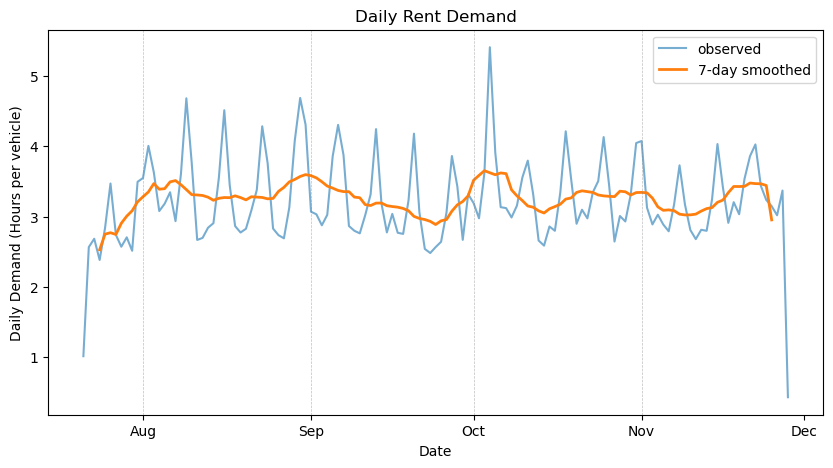

In [12]:
# Filter

movement_df_filtered = movement_df[movement_df['move_duration'] <= one_day].copy()

daily_use_filtered = movement_df_filtered.groupby('date')['rental_minutes'].sum().reset_index()
daily_use_filtered['total_hours'] = daily_use_filtered['rental_minutes'] / 60
daily_use_filtered['av_rent_hour_per_car'] = daily_use_filtered['total_hours'] / n_cars

daily_use_filtered = daily_use_filtered.sort_values('date')

daily_use_filtered['rental_smooth'] = daily_use_filtered['av_rent_hour_per_car'].rolling(window=7, center=True).mean()

# New plot
plt.figure(figsize=(10,5))
plt.plot(daily_use_filtered['date'], daily_use_filtered['av_rent_hour_per_car'], label='observed', alpha=0.6)
plt.plot(daily_use_filtered['date'], daily_use_filtered['rental_smooth'], label='7-day smoothed', linewidth=2)

ax = plt.gca()
for d in pd.date_range(daily_use_filtered['date'].min(), daily_use_filtered['date'].max(), freq='MS'):
    ax.axvline(d, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax.xaxis.set_major_locator(mdates.MonthLocator())       
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  

plt.xlabel('Date')
plt.ylabel('Daily Demand (Hours per vehicle)')
plt.title('Daily Rent Demand')
plt.legend()

plt.savefig('../artifacts/daily_rent_demand.png', dpi=300, bbox_inches='tight')
plt.show()

### Day of week/month popularity

Aggregating by day of the month (only August, September, October) >> full months

In [13]:
full_months = ['2025-08', '2025-09', '2025-10']  

movement_df_filtered['date'] = pd.to_datetime(movement_df_filtered['date'])

movement_df_3m = movement_df_filtered[
    movement_df_filtered['date'].dt.to_period('M').astype(str).isin(full_months)
].copy()

In [14]:
movement_df_3m['day_of_month'] = movement_df_3m['date'].dt.day
movement_df_3m['day_of_week'] = movement_df_3m['date'].dt.day_name()
movement_df_3m['month'] = movement_df_3m['date'].dt.strftime('%Y-%m')

dom_pattern = (
    movement_df_3m.groupby('day_of_month')['rental_minutes'].sum()
    / 60 / n_cars
)
dow_pattern = (
    movement_df_3m.groupby('day_of_week')['rental_minutes'].sum()
    / 60 / n_cars 
)

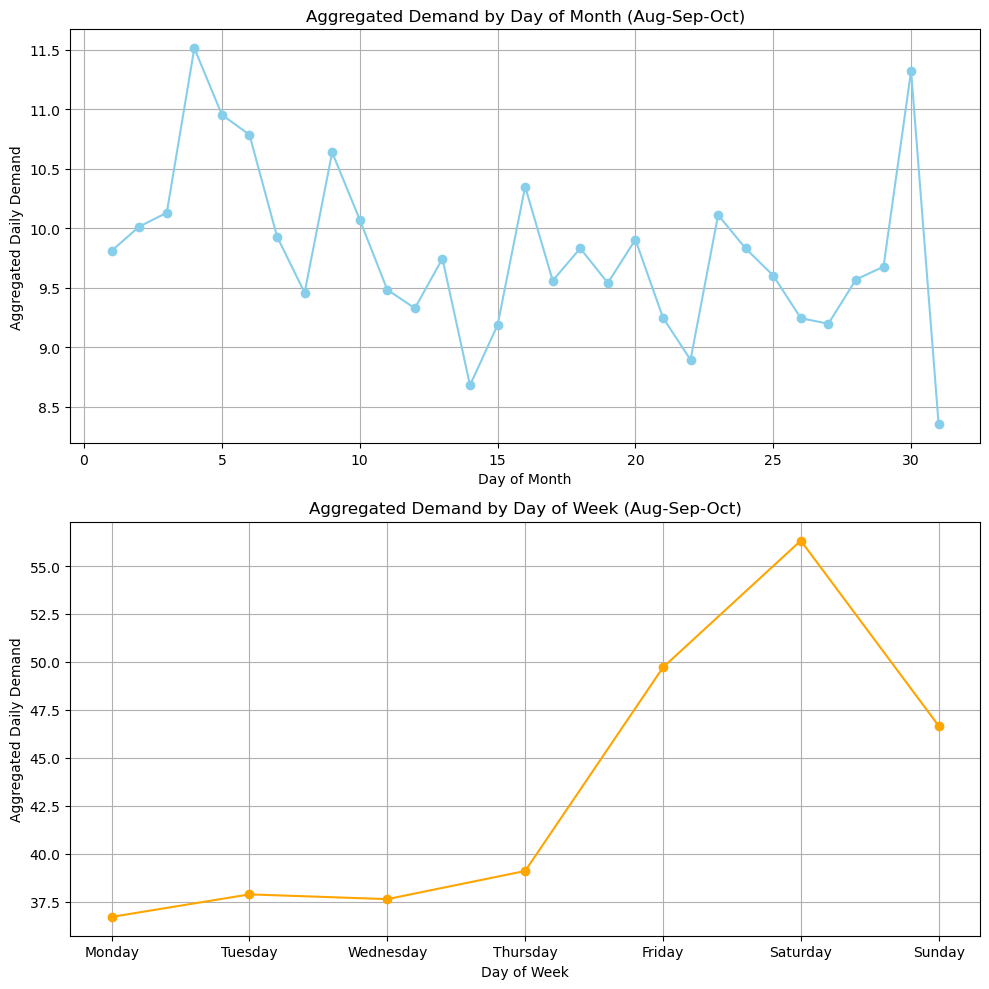

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))  # 2 rows, 1 column

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_pattern = dow_pattern.reindex(dow_order)

axes[0].plot(dom_pattern.index, dom_pattern.values, marker='o', color='skyblue')
axes[0].set_xlabel("Day of Month")
axes[0].set_ylabel("Aggregated Daily Demand")
axes[0].set_title("Aggregated Demand by Day of Month (Aug-Sep-Oct)")
axes[0].grid(True)

axes[1].plot(dow_pattern.index, dow_pattern.values, marker='o', color='orange')
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Aggregated Daily Demand")
axes[1].set_title("Aggregated Demand by Day of Week (Aug-Sep-Oct)")
axes[1].grid(True)
plt.tight_layout()

plt.savefig('../artifacts/dom-dow.png',dpi=300)
plt.show()

In [36]:
# For consistency in plots

import matplotlib as mpl
mpl.rcParams['font.size'] = 13
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 13
mpl.rcParams['xtick.labelsize'] = 11
mpl.rcParams['ytick.labelsize'] = 11

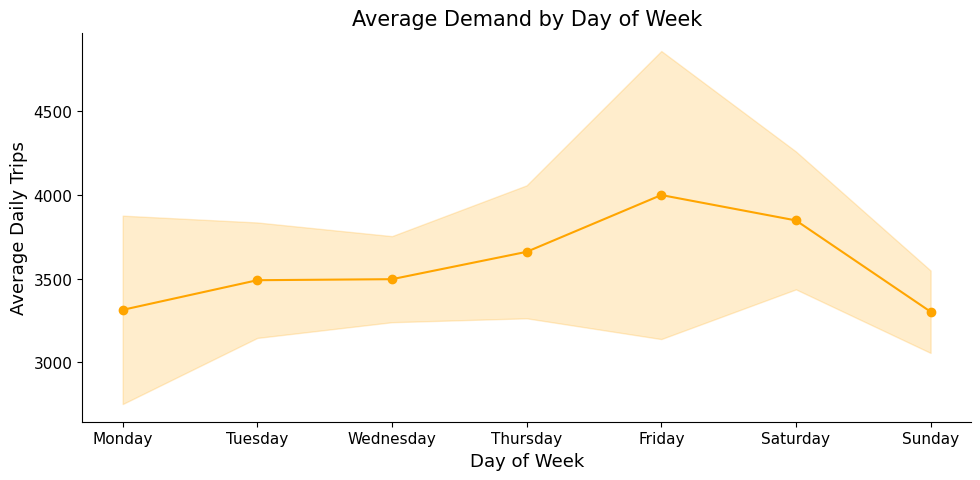

In [37]:
# Only Day-Of-Week

fig, ax = plt.subplots(figsize=(10, 5))

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

movement_df['dow'] = movement_df['start_move_time'].dt.day_name()
daily_counts = movement_df.groupby([movement_df['start_move_time'].dt.date, 'dow'])['licencePlate'].count().reset_index()
daily_counts.columns = ['date', 'dow', 'count']

dow_mean = daily_counts.groupby('dow')['count'].mean().reindex(dow_order)
dow_std = daily_counts.groupby('dow')['count'].std().reindex(dow_order)

ax.plot(dow_mean.index, dow_mean.values, marker='o', color='orange')
ax.fill_between(dow_mean.index, dow_mean - dow_std, dow_mean + dow_std, alpha=0.2, color='orange')

ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Daily Trips")
ax.set_title("Average Demand by Day of Week")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../artifacts/dow.png', dpi=300, bbox_inches='tight')
plt.show()

#### Demand by hour of the day

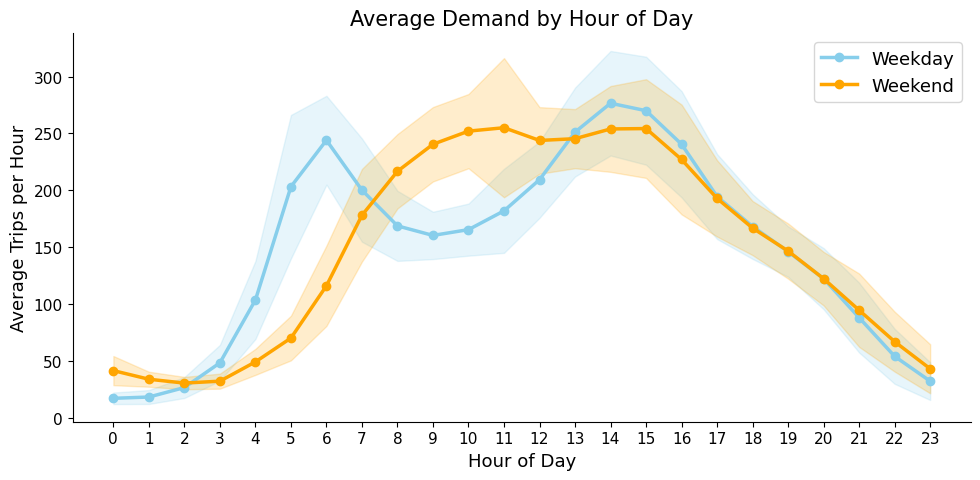

In [41]:
movement_df['hour'] = movement_df['start_move_time'].dt.hour
movement_df['is_weekend'] = movement_df['start_move_time'].dt.dayofweek >= 5

weekday_df = movement_df[movement_df['is_weekend'] == False]
weekend_df = movement_df[movement_df['is_weekend'] == True]

n_weekdays = weekday_df['start_move_time'].dt.date.nunique()
n_weekends = weekend_df['start_move_time'].dt.date.nunique()

weekday = weekday_df.groupby('hour')['licencePlate'].count() / n_weekdays
weekend = weekend_df.groupby('hour')['licencePlate'].count() / n_weekends

weekday_std = weekday_df.groupby([weekday_df['start_move_time'].dt.date, 'hour'])['licencePlate'].count().groupby('hour').std()
weekend_std = weekend_df.groupby([weekend_df['start_move_time'].dt.date, 'hour'])['licencePlate'].count().groupby('hour').std()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(weekday.index, weekday.values, marker='o', color='skyblue', linewidth=2.5, label='Weekday')
ax.fill_between(weekday.index, weekday - weekday_std, weekday + weekday_std, alpha=0.2, color='skyblue')

ax.plot(weekend.index, weekend.values, marker='o', color='orange', linewidth=2.5, label='Weekend')
ax.fill_between(weekend.index, weekend - weekend_std, weekend + weekend_std, alpha=0.2, color='orange')

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Trips per Hour")
ax.set_title("Average Demand by Hour of Day")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../artifacts/hourly_demand.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
movement_df.head(1)

,licencePlate,car_type,vehicleTypeId,start_move_time,end_move_time,start_lat,start_lon,end_lat,end_lon,start_zip,end_zip,start_area_name,end_area_name,move_duration,rental_minutes,date,hour,is_weekend,dow
0,bn32098,car,2,2025-07-22 09:13:00,2025-07-22 09:17:00,55.658398,12.514628,55.658348,12.515684,2500,2500,Valby,Valby,0 days 00:04:00,4.0,2025-07-22,9,False,Tuesday


In [40]:
movement_df.tail(1)

,licencePlate,car_type,vehicleTypeId,start_move_time,end_move_time,start_lat,start_lon,end_lat,end_lon,start_zip,end_zip,start_area_name,end_area_name,move_duration,rental_minutes,date,hour,is_weekend,dow
469809,en53362,car,2,2025-11-27 15:05:00,2025-11-27 16:05:00,55.702938,12.528683,55.656689,12.502694,2400,2500,Kobenhavn NV,Valby,0 days 00:59:59,59.983333,2025-11-27,15,False,Thursday
